CELDA 0: 
Descomentar el código para instalar pymfe y openml en el entorno, necesarios para ejecutar el código

In [5]:
#Instalar pymfe y openml 
 #!pip install -U openml
 #pip install pymfe

CELDA 1:
Aqui defino la semilla y los imports.

In [1]:
# Configuración inicial
SEED = 42

# 1. Librerías estándar de Python
import gc  # Garbage collector para liberar memoria activamente
import os
import time

# 2. Manejo de datos y utilidades
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype

# 3. Visualización
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# 4. Librerías específicas de datos y meta-características
import openml
from pymfe.mfe import MFE

# 5. Scikit-learn (Machine Learning) agrupado por submódulos
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
    RandomForestRegressor,
    VotingClassifier
)
from sklearn.feature_selection import SelectKBest, VarianceThreshold, chi2, f_classif, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, LogisticRegression, Ridge
from sklearn.metrics import accuracy_score
from sklearn.model_selection import LeaveOneOut, StratifiedKFold, cross_val_score, train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler



 CELDA 2:
Función de imputación, anteriormente la celda contenía el código respectivo a openml, pero se unificó todo en la celda 4, he dejado aquí la función para no cargarla más.
Se ha añadido dropear las columnas que tengan todo NaN o, al menos un 95%. Se hace calculandoo col_all_nan, que contiene el indice de las columnas que sean nan, y cols_casi_nan, que contiene el de las que son al menos un 95% NaN.


In [4]:


def imputar_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    #busca las columnas que contengan todo NaN, y las dropea
    cols_all_nan = df.columns[df.isna().all()]
    if len(cols_all_nan) > 0:
        df = df.drop(columns=cols_all_nan) 
    #busca las columnas que tengan mas de un 95 % de NaNs, y también las dropea 
    pct_nan = df.isna().mean() 
    cols_casi_nan = pct_nan[pct_nan > 0.95].index 
    if len(cols_casi_nan) > 0:
        df = df.drop(columns=cols_casi_nan)
    # Imputa el resto: mediana para numéricas, moda para categóricas
    for col in df.columns:
        serie = df[col]

        if is_numeric_dtype(serie):
            df[col] = serie.fillna(float(serie.median()))
   
        else:
            moda = serie.mode(dropna=True)
            df[col] = serie.fillna(moda.iloc[0])

    return df




CELDA 3: Extracción de meta-features
Importante: hay que tener instalado pymfe, abajo está comentado por si no se tiene.

Convertir a float es una buena práctica para que pandas y scikit learn puedan trabajar con los meta atributos sin problemas.
limpiar_nombre_meta_feature es necesario para normalizar los nombres de los meta atributos y estén así más homogéneos para manejarlos luego.
Por último , cat_cols es necesario para identificar qué columnas del dataset deben tratarse como categóricas. En concreto, guarda los índices de las columnas de tipo texto, categórico o booleano, para que PyMFE sepa interpretarlas correctamente al extraer los meta-atributos.
Pymfe suelta muchos warnings pero no hay de que preocuparse, son warnings que avisan de que que ciertos meta-atributos no pueden calcularse correctamente para algunos datasets, entonces los sustituye por NaN.

In [5]:


# Grupos a usar para meta-features (alineados con paper Parmezan et al. 2021)
GRUPOS_MFE = [
    "general",
    "statistical",
    "info-theory",
    "complexity",
    "landmarking",
    "model-based",
]
# Resúmenes estadísticos que se calculan para cada meta-atributo multivaluado
RESUMENES_MFE = ["mean", "sd", "min", "max"]

# Normaliza el nombre para que no haya caracteres que rompan pandas o sklearn
def limpiar_nombre_meta_feature(nombre):
    return (
        str(nombre)
        .replace(".", "_").replace("-", "_").replace(" ", "_")
        .replace("(", "").replace(")", "").replace("/", "_")
        .replace(":", "_").lower()
    )

# Convierte cualquier valor a float; si no es posible, devuelve NaN
def convertir_a_float(valor):
    try:
        if pd.isna(valor):
            return np.nan
        return float(valor)
    except Exception:
        return np.nan


def extraer_meta_features_pymfe(X_df, y):
    X_df = X_df.copy()
    y = pd.Series(y).reset_index(drop=True)
    
 # Devuelve los índices de las columnas categóricas (texto, categoría, booleano)
 # pymfe necesita saberlo para no tratar esas columnas como numérica
    def _cat_cols(df):
        return [
            i for i, col in enumerate(df.columns)
            if pd.api.types.is_object_dtype(df[col])
            or isinstance(df[col].dtype, pd.CategoricalDtype)
            or pd.api.types.is_bool_dtype(df[col])
        ]
     # Función interna que lanza pymfe para un subconjunto de meta-atributos
    def _extraer_bloque(features, summary=None, X_fit_df=None, y_fit=None):
        X_fit_df = X_df if X_fit_df is None else X_fit_df
        y_fit = y if y_fit is None else pd.Series(y_fit).reset_index(drop=True)

        X_fit = X_fit_df.to_numpy()
        cat_cols = _cat_cols(X_fit_df)

        mfe = MFE(
            groups=GRUPOS_MFE,
            features=features,
            summary=summary,
            suppress_warnings=True,
        )
        mfe.fit(X_fit, y_fit.to_numpy(), cat_cols=cat_cols)
        nombres, valores = mfe.extract()

        bloque = {}
        for nombre, valor in zip(nombres, valores):
            nombre_limpio = limpiar_nombre_meta_feature(nombre)
            if isinstance(valor, (list, tuple, np.ndarray)):
                valor = np.asarray(valor).ravel()
                if valor.size == 1:
                    valor = valor.item()
                else:
                    # Si pymfe devuelve un array de más de un elemento, no sabemos
                    # cómo resumirlo aquí → NaN
                    bloque[nombre_limpio] = np.nan
                    continue
            bloque[nombre_limpio] = convertir_a_float(valor)
        return bloque

    meta = {}

    # =========================================================
    # 1) CUSTOM
    # =========================================================
    class_counts = y.value_counts(dropna=False)
    max_class = int(class_counts.max()) if len(class_counts) > 0 else 0
    min_class = int(class_counts.min()) if len(class_counts) > 0 else 0
    
    # Ratio entre la clase minoritaria y la mayoritaria (1.0 = dataset perfectamente balanceado)
    meta["class_balance_ratio"] = (
        convertir_a_float(min_class / max_class) if max_class > 0 else np.nan
    )
    # Error del clasificador naive (predice siempre la clase mayoritaria)
    meta["majority_class_error"] = (
        convertir_a_float(1.0 - (max_class / len(y))) if len(y) > 0 else np.nan
    )

    # =========================================================
    # 2) SIMPLES
    # =========================================================
    try:
        bloque = _extraer_bloque(
            features=["nr_inst", "nr_attr", "nr_class", "nr_num", "nr_cat", "nr_bin", "attr_to_inst"],
            summary=None,
        )
        for k in ["nr_inst", "nr_attr", "nr_class", "nr_num", "nr_cat", "nr_bin", "attr_to_inst"]:
            meta[k] = bloque.get(k, np.nan)
    except Exception:
        for k in ["nr_inst", "nr_attr", "nr_class", "nr_num", "nr_cat", "nr_bin", "attr_to_inst"]:
            meta.setdefault(k, np.nan)

    try:
        bloque = _extraer_bloque(features=["freq_class"], summary=["mean", "sd", "min", "max"])
        for k in ["freq_class_mean", "freq_class_sd", "freq_class_min", "freq_class_max"]:
            meta[k] = bloque.get(k, np.nan)
    except Exception:
        for k in ["freq_class_mean", "freq_class_sd", "freq_class_min", "freq_class_max"]:
            meta.setdefault(k, np.nan)

    # =========================================================
    # 3) STATISTICAL
    # =========================================================
    try:
        bloque = _extraer_bloque(features=["skewness", "kurtosis", "cor"], summary=["mean", "sd", "min", "max"])
        for k in [
            "skewness_mean", "skewness_sd", "skewness_min", "skewness_max",
            "kurtosis_mean", "kurtosis_sd", "kurtosis_min", "kurtosis_max",
            "cor_mean", "cor_sd", "cor_min", "cor_max",
        ]:
            meta[k] = bloque.get(k, np.nan)
    except Exception:
        for k in [
            "skewness_mean", "skewness_sd", "skewness_min", "skewness_max",
            "kurtosis_mean", "kurtosis_sd", "kurtosis_min", "kurtosis_max",
            "cor_mean", "cor_sd", "cor_min", "cor_max",
        ]:
            meta.setdefault(k, np.nan)

    # Coeficiente de variación calculado a mano (más estable que el de pymfe)
    try:
        X_num = X_df.select_dtypes(include=[np.number]).copy()
        if X_num.shape[1] > 0:
            means = X_num.mean(axis=0, skipna=True).replace(0, np.nan)
            stds = X_num.std(axis=0, skipna=True)
            vc = (stds / means).replace([np.inf, -np.inf], np.nan).dropna()
            meta["var_coefficient_mean"] = convertir_a_float(vc.mean()) if len(vc) else np.nan
            meta["var_coefficient_sd"]   = convertir_a_float(vc.std())  if len(vc) else np.nan
            meta["var_coefficient_min"]  = convertir_a_float(vc.min())  if len(vc) else np.nan
            meta["var_coefficient_max"]  = convertir_a_float(vc.max())  if len(vc) else np.nan
        else:
            for k in ["var_coefficient_mean", "var_coefficient_sd", "var_coefficient_min", "var_coefficient_max"]:
                meta[k] = np.nan
    except Exception:
        for k in ["var_coefficient_mean", "var_coefficient_sd", "var_coefficient_min", "var_coefficient_max"]:
            meta.setdefault(k, np.nan)

    try:
        bloque = _extraer_bloque(features=["nr_cor_attr", "nr_outliers"], summary=None)
        meta["nr_cor_attr"] = bloque.get("nr_cor_attr", np.nan)
        meta["nr_outliers"] = bloque.get("nr_outliers", np.nan)
    except Exception:
        for k in ["nr_cor_attr", "nr_outliers"]:
            meta.setdefault(k, np.nan)

    # =========================================================
    # 4) INFO-THEORY
    # =========================================================
    try:
        bloque = _extraer_bloque(features=["class_ent", "eq_num_attr", "ns_ratio"], summary=None)
        meta["class_ent"]   = bloque.get("class_ent", np.nan)
        meta["eq_num_attr"] = bloque.get("eq_num_attr", np.nan)
        meta["ns_ratio"]    = bloque.get("ns_ratio", np.nan)
    except Exception:
        for k in ["class_ent", "eq_num_attr", "ns_ratio"]:
            meta.setdefault(k, np.nan)

    try:
        bloque = _extraer_bloque(features=["attr_ent", "mut_inf", "joint_ent"], summary=["mean", "sd", "min", "max"])
        for k in [
            "attr_ent_mean", "attr_ent_sd", "attr_ent_min", "attr_ent_max",
            "mut_inf_mean", "mut_inf_sd", "mut_inf_min", "mut_inf_max",
            "joint_ent_mean", "joint_ent_sd", "joint_ent_min", "joint_ent_max",
        ]:
            meta[k] = bloque.get(k, np.nan)
    except Exception:
        for k in [
            "attr_ent_mean", "attr_ent_sd", "attr_ent_min", "attr_ent_max",
            "mut_inf_mean", "mut_inf_sd", "mut_inf_min", "mut_inf_max",
            "joint_ent_mean", "joint_ent_sd", "joint_ent_min", "joint_ent_max",
        ]:
            meta.setdefault(k, np.nan)

    try:
        bloque = _extraer_bloque(features=["class_conc"], summary=["mean", "sd", "min", "max"])
        for k in ["class_conc_mean", "class_conc_sd", "class_conc_min", "class_conc_max"]:
            meta[k] = bloque.get(k, np.nan)
    except Exception:
        for k in ["class_conc_mean", "class_conc_sd", "class_conc_min", "class_conc_max"]:
            meta.setdefault(k, np.nan)

     # =========================================================
    # 5) COMPLEXITY
    # =========================================================
    try:
        # Escalares: summary=None funciona porque devuelven un único valor
        bloque = _extraer_bloque(
            features=["density", "c1", "c2", "n1", "t2"],
            summary=None
        )
        meta["density"] = bloque.get("density", np.nan)
        meta["c1"]      = bloque.get("c1",      np.nan)
        meta["c2"]      = bloque.get("c2",      np.nan)
        meta["n1"]      = bloque.get("n1",      np.nan)
        meta["t2"]      = bloque.get("t2",      np.nan)
    except Exception:
        for k in ["density", "c1", "c2", "n1", "t2"]:
            meta.setdefault(k, np.nan)
    
    try:
        # Multi-valor: f1, n2, n3, n4 devuelven arrays → necesitan summary="mean"
        # Con summary=["mean"], pymfe devuelve "f1.mean", "n2.mean"...
        # que limpiar_nombre_meta_feature convierte a "f1_mean", "n2_mean"...
        bloque = _extraer_bloque(
            features=["f1", "n2", "n3", "n4"],
            summary=["mean"]
        )
        meta["f1"]      = bloque.get("f1_mean",  np.nan)
        meta["n2_mean"] = bloque.get("n2_mean",  np.nan)
        meta["n3_mean"] = bloque.get("n3_mean",  np.nan)
        meta["n4"]      = bloque.get("n4_mean",  np.nan)
    except Exception:
        for k in ["f1", "n2_mean", "n3_mean", "n4"]:
            meta.setdefault(k, np.nan)
    
    # =========================================================
    # 6) LANDMARKING
    # =========================================================
    try:
        # Multi-valor: cada landmark devuelve accuracy por fold → summary="mean"
        # Con summary=["mean"], pymfe devuelve "best_node.mean" → "best_node_mean"
        # que coincide exactamente con las claves que ya usamos abajo
        bloque = _extraer_bloque(
            features=[
                "best_node", "random_node", "linear_discr",
                "elite_nn", "naive_bayes", "one_nn", "worst_node",
            ],
            summary=["mean"],
        )
        meta["best_node_mean"]    = bloque.get("best_node_mean",    np.nan)
        meta["random_node_mean"]  = bloque.get("random_node_mean",  np.nan)
        meta["linear_discr_mean"] = bloque.get("linear_discr_mean", np.nan)
        meta["elite_nn_mean"]     = bloque.get("elite_nn_mean",     np.nan)
        meta["naive_bayes_mean"]  = bloque.get("naive_bayes_mean",  np.nan)
        meta["one_nn_mean"]       = bloque.get("one_nn_mean",       np.nan)
        meta["worst_node_mean"]   = bloque.get("worst_node_mean",   np.nan)
    except Exception:
        for k in [
            "best_node_mean", "random_node_mean", "linear_discr_mean",
            "elite_nn_mean", "naive_bayes_mean", "one_nn_mean", "worst_node_mean",
        ]:
            meta.setdefault(k, np.nan)
    # =========================================================
    # 7) MODEL-BASED
    # =========================================================
    try:
        bloque = _extraer_bloque(features=["nodes", "leaves"], summary=None)
        meta["nodes"] = bloque.get("nodes", np.nan)
        meta["leaves"] = bloque.get("leaves", np.nan)
    except Exception:
        for k in ["nodes", "leaves"]:
            meta.setdefault(k, np.nan)

    try:
        bloque = _extraer_bloque(
            features=["tree_depth", "leaves_branch", "nodes_per_level", "var_importance"],
            summary=["mean", "max"],
        )

        meta["tree_depth_mean"] = bloque.get("tree_depth_mean", np.nan)
        meta["tree_depth_max"] = bloque.get("tree_depth_max", np.nan)

        meta["leaves_branch_mean"] = bloque.get("leaves_branch_mean", np.nan)
        meta["leaves_branch_max"] = bloque.get("leaves_branch_max", np.nan)

        meta["nodes_per_level_mean"] = bloque.get("nodes_per_level_mean", np.nan)
        meta["nodes_per_level_max"] = bloque.get("nodes_per_level_max", np.nan)

        meta["var_importance_mean"] = bloque.get("var_importance_mean", np.nan)
        meta["var_importance_max"] = bloque.get("var_importance_max", np.nan)
    except Exception:
        for k in [
            "tree_depth_mean", "tree_depth_max",
            "leaves_branch_mean", "leaves_branch_max",
            "nodes_per_level_mean", "nodes_per_level_max",
            "var_importance_mean", "var_importance_max",
        ]:
            meta.setdefault(k, np.nan)


    
    try:
        bloque = _extraer_bloque(features=["leaves_per_class"], summary=["mean", "sd", "min", "max"])
        for k in [
            "leaves_per_class_mean",
            "leaves_per_class_sd",
            "leaves_per_class_min",
            "leaves_per_class_max",
        ]:
            meta[k] = bloque.get(k, np.nan)
    except Exception:
        for k in [
            "leaves_per_class_mean",
            "leaves_per_class_sd",
            "leaves_per_class_min",
            "leaves_per_class_max",
        ]:
            meta.setdefault(k, np.nan)

    return meta


CELDA 4 - Construcción del meta-dataset

Esta celda es el núcleo del experimento. Para cada dataset, hace dos cosas: evalúa qué selector de características funciona mejor y extrae sus meta-características. El resultado es una fila del meta-dataset.

**¿Cómo se decide el mejor selector?**

Se comparan tres selectores: `chi2`, `mutual_info` y `f_classif`. Los tres funcionan con `SelectKBest`, que puntúa cada columna usando la función que le pases y se queda con las *k* mejores. El número *k* es la raíz cuadrada del número de features del dataset, con un mínimo de 2.

Cada selector se evalúa dentro de un pipeline con un RandomForest y validación cruzada de 5 folds. El ganador no se elige solo por accuracy: se calcula un **score compuesto** que también penaliza la varianza entre folds y el tiempo de ejecución. Así se evita que un selector gane por una diferencia mínima que podría ser puro ruido.

Una nota sobre chi2: no acepta valores negativos, así que los datos pasan primero por un `MinMaxScaler` que los lleva al rango [0, 1].

La función `preparar_X_e_y` adapta cada dataset al formato que necesita sklearn: convierte columnas categóricas a numéricas con one-hot encoding y codifica la variable objetivo si no es ya numérica.

Por último, hay una lista negra de tasks que hacen colgar pymfe. Se excluyen manualmente antes de entrar al bucle.

In [9]:


# ─── PESOS DEL SCORE COMPUESTO (parametrizables ) ──────────────

W_ACC    = 0.7  
W_STD    = 0.2   
W_TIEMPO = 0.1   

NOMBRES_SELECTORES = ["chi2", "mutual_info", "f_classif"]
MAX_INSTANCIAS = 30_000   # antes: 20_000
MAX_FEATURES   = 1_000     # antes: 500
MAX_CLASES     = 50        # se mantiene igual

def _normalizar_local(valores: np.ndarray) -> np.ndarray:
    """
    Min-max LOCAL entre los 3 selectores del MISMO dataset.
    Si los 3 valores son iguales → empate técnico → 0.5 a todos.
    """
    rango = valores.max() - valores.min()
    if rango == 0:
        return np.full_like(valores, 0.5, dtype=float)
    return (valores - valores.min()) / rango


def calcular_scores_compuestos(resultados: dict,
                                w_acc: float = W_ACC,
                                w_std: float = W_STD,
                                w_tiempo: float = W_TIEMPO) -> dict:
    """
    Score compuesto por selector dentro de UN dataset.

    score = w_acc * norm(acc) - w_std * norm(std) - w_tiempo * norm(tiempo)

    La normalización es LOCAL entre los 3 selectores del mismo dataset.
    """
    nombres = list(resultados.keys())

    accs    = np.array([resultados[s]["acc_media"] for s in nombres])
    stds    = np.array([resultados[s]["acc_std"]   for s in nombres])
    tiempos = np.array([resultados[s]["tiempo"]    for s in nombres])
    # Normalizamos cada métrica entre 0 y 1 dentro del mismo dataset
    norm_acc    = _normalizar_local(accs)
    norm_std    = _normalizar_local(stds)
    norm_tiempo = _normalizar_local(tiempos)
    
    scores_arr = w_acc * norm_acc - w_std * norm_std - w_tiempo * norm_tiempo

    return dict(zip(nombres, scores_arr))


def preparar_X_e_y(X_df, y):
    """
    Adapta el dataset al formato que necesitan los selectores y el clasificador.
    - Variables categóricas → one-hot encoding (sklearn solo trabaja con números)
    - Variable objetivo → label encoding si no es ya numérica
    """
    X = pd.get_dummies(X_df, drop_first=False)

    y = pd.Series(y).copy()
    if y.dtype == "object" or isinstance(y.dtype, pd.CategoricalDtype) or pd.api.types.is_bool_dtype(y):
        y = LabelEncoder().fit_transform(y.astype(str))

    return X, y


def evaluar_selectores_en_dataset(X_df, y, seed=SEED):
    """
    Evalúa los 3 selectores con CV de 5 folds y devuelve scores compuestos.
    Las métricas brutas (acc, std, tiempo) NO se exponen al meta-dataset:
    se usan solo internamente para calcular el score compuesto.
    """
    X, y = preparar_X_e_y(X_df, y)
     # k = número de features a seleccionar: raíz cuadrada del total,
    # con un mínimo de 2 para que el selector tenga sentido
    k = max(2, int(np.sqrt(X.shape[1])))

    selectores_config = {
        "chi2":        {"score_func": chi2,                "usar_minmax": True},
        "mutual_info": {"score_func": mutual_info_classif, "usar_minmax": False},
        "f_classif":   {"score_func": f_classif,           "usar_minmax": False},
    }

    resultados = {}
  
    # n_splits no puede superar el número de muestras de la clase minoritaria
    min_samples_clase = int(pd.Series(y).value_counts().min())
    n_splits = min(5, min_samples_clase)
    if n_splits < 2:
        # Con menos de 2 muestras en alguna clase no tiene sentido evaluar
        raise ValueError(f"Clase minoritaria con solo {min_samples_clase} muestra/s")
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for nombre_selector, config in selectores_config.items():
        try:
            if config["usar_minmax"]:
                pipe = Pipeline([
                    ("scaler",   MinMaxScaler()),
                    ("selector", SelectKBest(score_func=config["score_func"], k=k)),
                    ("clf",      RandomForestClassifier(n_estimators=100, random_state=seed)),
                ])
            else:
                pipe = Pipeline([
                    ("selector", SelectKBest(score_func=config["score_func"], k=k)),
                    ("clf",      RandomForestClassifier(n_estimators=100, random_state=seed)),
                ])

            t_inicio = time.time()
            scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
            resultados[nombre_selector] = {
                "acc_media": scores.mean(),
                "acc_std":   scores.std(),
                "tiempo":    time.time() - t_inicio,
            }

        except Exception as e:
            print(f"  ⚠ {nombre_selector} falló en este dataset: {e}")
            resultados[nombre_selector] = {"acc_media": 0.0, "acc_std": 1.0, "tiempo": 1e6}

    scores_compuestos = calcular_scores_compuestos(resultados)
    mejor_selector    = max(scores_compuestos, key=scores_compuestos.get)

    return scores_compuestos, mejor_selector


def procesar_dataset_completo(task_id, seed=SEED):
    """
    Carga un dataset, calcula scores compuestos y extrae meta-features.
    Devuelve UNA fila del meta-dataset.
    """
    try:
        task    = openml.tasks.get_task(task_id)
        dataset = openml.datasets.get_dataset(task.dataset_id)
        target_name = dataset.default_target_attribute or getattr(task, "target_name", None)
        if target_name is None:
            return None

        X_df, y, _, _ = dataset.get_data(dataset_format="dataframe", target=target_name)
        y = pd.Series(y)

        # Filtro de tamaño defensivo
        if X_df.shape[0] > MAX_INSTANCIAS or X_df.shape[1] > MAX_FEATURES:
            print(f"  ↷ Saltado (tamaño real): {dataset.name}")
            return None

        mascara = y.notna().values
        X_df = X_df.loc[mascara].reset_index(drop=True)
        y    = y.loc[mascara].reset_index(drop=True)
        X_df = imputar_dataframe(X_df)

        nombre = f"{dataset.name}_{task_id}"

        scores_compuestos, mejor_selector = evaluar_selectores_en_dataset(X_df, y, seed=seed)
        meta = extraer_meta_features_pymfe(X_df, y)

        fila = {"dataset_name": nombre, "best_selector": mejor_selector}
        fila.update(meta)
        for sel in NOMBRES_SELECTORES:
            fila[f"score_{sel}"] = scores_compuestos[sel]

        return fila

    except Exception as e:
        print(f"  ✗ Error en task {task_id}: {e}")
        return None

    finally:
        try:
            del X_df, y
        except Exception:
            pass
        gc.collect()




# ─── 1) TASKS DE LAS SUITES ─────────────────────────

suite1 = openml.study.get_suite("OpenML-CC18")
suite2 = openml.study.get_suite("14")
suite3 = openml.study.get_suite("270")
suite4 = openml.study.get_suite("334")
suite5 = openml.study.get_suite("379")

task_ids_suites = list(set(
    list(suite1.tasks) +
    list(suite2.tasks) +
    list(suite3.tasks) +
    list(suite4.tasks) +
    list(suite5.tasks)
))
print(f"Tasks totales de las suites (CC18 + 14 + 270 + 334 + 379): {len(task_ids_suites)}")

# ─── 2) UNIÓN FINAL Y BUCLE PRINCIPAL ───────────────────────────────────────
task_ids = task_ids_suites
print(f"Total de tasks a procesar: {len(task_ids)}\n")

filas_meta = []
for i, task_id in enumerate(task_ids, start=1):
    print(f"[{i}/{len(task_ids)}] task_id={task_id}")
    fila = procesar_dataset_completo(task_id)
    if fila is not None:
        filas_meta.append(fila)
        print(f"  ✓ {fila['dataset_name']} — mejor selector: {fila['best_selector']}")

meta_dataset_df = pd.DataFrame(filas_meta)
print(f"\nMeta-dataset final: {meta_dataset_df.shape[0]} datasets × {meta_dataset_df.shape[1]} columnas")




Tasks totales de las suites (CC18 + 14 + 270 + 334 + 379): 171
Total de tasks a procesar: 171

[1/171] task_id=3
  ✓ kr-vs-kp_3 — mejor selector: chi2
[2/171] task_id=6


C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It

  ✓ letter_6 — mejor selector: chi2
[3/171] task_id=7
  ✗ Error en task 7: Clase minoritaria con solo 1 muestra/s
[4/171] task_id=10


C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It

  ✓ lymph_10 — mejor selector: mutual_info
[5/171] task_id=11


...

  ✓ analcatdata_dmft_3560 — mejor selector: mutual_info
[169/171] task_id=3561


C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It

  ✓ profb_3561 — mejor selector: f_classif
[170/171] task_id=3567


C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\statistical.py:208: RuntimeWarning: divide by zero encountered in divide
  can_cor_eig_vals = sqr_can_cors / (1 - sqr_can_cors)
C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\statistical.py:208: RuntimeWarning: divide by zero encountered in divide
  can_cor_eig_vals = sqr_can_cors / (1 - sqr_can_cors)
C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\pymfe\complexity.py:804: RuntimeWarning: divide by zero encountered in divide
  attr_discriminant_ratio = _numer / _denom
C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 6 members, which is less than n_splits=10.
  warnings.warn(
C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 6 members, which is less than n_splits=10.
  warnings.wa

  ✓ collins_3567 — mejor selector: f_classif
[171/171] task_id=3573
  ↷ Saltado (tamaño real): mnist_784

Meta-dataset final: 126 datasets × 85 columnas


In [10]:
meta_dataset_df
meta_dataset_df.to_pickle("meta_dataset_df2.pkl")
meta_dataset_df.to_csv("meta_dataset_df2.csv", index=False)

Celda de cara a reutilización del meta dataset si no se tenía en el kernel, ya que en la celda anterior se descargaba. De esta forna puedo iterar con el resto de celdas sin esperar horas a que se extraigan los meta features.

In [2]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Recuperar meta-dataset guardado
meta_dataset_df = pd.read_pickle("meta_dataset_df2.pkl")
print(f"Meta-dataset cargado: {meta_dataset_df.shape[0]} datasets × {meta_dataset_df.shape[1]} columnas")

# Preparar X e y (base para todos los modelos)
score_cols   = ["score_chi2", "score_mutual_info", "score_f_classif"]
cols_excluir = ["dataset_name", "best_selector"] + score_cols
NOMBRES_SELECTORES = ["chi2", "mutual_info", "f_classif"]
SEED = 42

X_raw = meta_dataset_df.drop(columns=cols_excluir, errors='ignore')
X_raw = X_raw.dropna(axis=1, how="all")
X_raw = X_raw.loc[:, X_raw.isnull().mean() < 0.50]
y     = meta_dataset_df["best_selector"].values

imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()
X_imp   = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)
X_sc    = pd.DataFrame(scaler.fit_transform(X_imp),  columns=X_raw.columns)

print(f"X lista: {X_sc.shape[0]} datasets × {X_sc.shape[1]} features")
print(f"Distribución y: {pd.Series(y).value_counts().to_dict()}")

Meta-dataset cargado: 126 datasets × 85 columnas
X lista: 126 datasets × 80 features
Distribución y: {'mutual_info': 52, 'chi2': 42, 'f_classif': 32}


CELDA 5- Modelo 1: clasificador directo con Leave-One-Out

El meta-dataset ya está construido. Ahora entrenamos un modelo que, dadas las meta-características de un dataset, prediga directamente cuál de los tres selectores es el mejor.

La evaluación se hace con **Leave-One-Out (LOO)**: en cada iteración se entrena con todos los datasets menos uno, y se predice ese uno. Dado que el meta-dataset no es enorme, LOO aprovecha al máximo los datos disponibles.

Hay un detalle importante en la imputación: los NaN que deja pymfe se imputan con la mediana, pero calculada **solo con los datos de entrenamiento de cada fold**. Hacerlo antes del LOO contaminaría la evaluación, porque la mediana del conjunto completo ya contendría información del dato de test.

Como clasificador se usa RandomForest, igual que en la evaluación de los selectores.

In [8]:
from sklearn.ensemble import RandomForestClassifier

# ─────────────────────────────────────────────────────────────────────────────
# CLASIFICADOR LOO
# Target: best_selector (etiqueta discreta del selector ganador por score compuesto)
# Aprende directamente la clase, sin pasar por scores intermedios.
# ─────────────────────────────────────────────────────────────────────────────

# Columnas que NO son meta-features y por tanto NO entran en X
score_cols   = [f"score_{sel}" for sel in NOMBRES_SELECTORES]
cols_excluir = ["dataset_name", "best_selector"] + score_cols

# X: solo meta-features (input del modelo)
X_meta = meta_dataset_df.drop(columns=cols_excluir).copy()
X_meta = X_meta.dropna(axis=1, how="all")  # quitar columnas que sean 100% NaN

# y: etiqueta discreta = mejor selector por score compuesto
y_label = meta_dataset_df["best_selector"].values

dataset_names = meta_dataset_df["dataset_name"].copy()
X_meta_arr    = X_meta.values

loo = LeaveOneOut()
y_pred_clf, y_real_clf, names_clf = [], [], []

for train_idx, test_idx in loo.split(X_meta_arr):
    X_tr, X_te = X_meta_arr[train_idx], X_meta_arr[test_idx]
    y_tr       = y_label[train_idx]

    # Imputación DENTRO del fold para evitar data leakage:
    # la mediana se calcula solo con los datos de entrenamiento del fold
    imputer = SimpleImputer(strategy="median")
    X_tr    = imputer.fit_transform(X_tr)
    X_te    = imputer.transform(X_te)

    # Clasificador estándar: predice una de las 3 clases directamente
    clf = RandomForestClassifier(n_estimators=200, random_state=SEED)
    clf.fit(X_tr, y_tr)

    y_pred_clf.append(clf.predict(X_te)[0])
    y_real_clf.append(y_label[test_idx[0]])
    names_clf.append(dataset_names.iloc[test_idx[0]])

loo_acc_clf = accuracy_score(y_real_clf, y_pred_clf)
print(f"LOO Accuracy — CLASIFICADOR: {loo_acc_clf:.4f}")

resultados_clf_df = pd.DataFrame({
    "dataset_name":       names_clf,
    "real_selector":      y_real_clf,
    "predicted_selector": y_pred_clf,
    "correcto":           [r == p for r, p in zip(y_real_clf, y_pred_clf)],
})
resultados_clf_df



LOO Accuracy — CLASIFICADOR: 0.5079


,dataset_name,real_selector,predicted_selector,correcto
0,kr-vs-kp_3,chi2,mutual_info,False
1,letter_6,chi2,mutual_info,False
2,lymph_10,mutual_info,chi2,False
3,balance-scale_11,mutual_info,chi2,False
4,mfeat-factors_12,mutual_info,chi2,False
...,...,...,...,...
121,Australian_125923,f_classif,mutual_info,False
122,gina_189922,mutual_info,mutual_info,True
123,analcatdata_dmft_3560,mutual_info,mutual_info,True
124,profb_3561,f_classif,chi2,False


CELDA 6- MODELO 2 - MODELO HÍBRIDO

Un clasificador directo de 3 clases trata `chi2`, `mutual_info` y `f_classif` como opciones equivalentes, perdiendo la información de cuánto se separan los scores entre sí. El modelo híbrido divide el problema en dos niveles más sencillos aprovechando que `chi2` tiene un comportamiento estructuralmente distinto a los otros dos selectores.

El **Nivel A** es un clasificador binario RandomForest entrenado con todos los datasets del fold de entrenamiento. Su única tarea es decidir si `chi2` es el mejor selector o no, transformando el target original de 3 clases en dos etiquetas: `chi2` o `no_chi2`.

El **Nivel B** entra en juego solo cuando el Nivel A predice `no_chi2`. Se trata de un regresor Ridge multi-salida (MultiOutputRegressor) entrenado únicamente con los datasets del fold donde `chi2` no es el ganador. En lugar de predecir una etiqueta discreta, predice simultáneamente el score compuesto de `f_classif` y el de `mutual_info`. El selector con mayor score predicho es la recomendación final.

La razón de usar regresión en el Nivel B, en lugar de un clasificador binario, es que el subconjunto de datasets sin `chi2` es reducido (~70-80 de los ~126 disponibles). Con tan pocos ejemplos, discretizar el target en una etiqueta binaria descarta información valiosa. Predecir el score continuo preserva la señal de cuánto se separan ambos selectores, no solo cuál gana, lo que aprovecha mejor los datos disponibles.

En ambos niveles, la imputación por mediana se ajusta dentro de cada fold para evitar data leakage. El StandardScaler del pipeline del Nivel B también se ajusta solo con los datos de entrenamiento del fold correspondiente.

In [19]:
# =============================================================================
# CELDA: Enfoque híbrido — clasificación nivel A + regresión nivel B
# =============================================================================
# Nivel A (clasificador): chi2 vs no_chi2 → entrenado con TODO el train.
# Nivel B (regresor):     2 regresores Ridge que predicen score_f_classif
#                          y score_mutual_info, SOLO con muestras no_chi2.
#                          Decisión por argmax de los 2 scores predichos.
#
# Justificación: el nivel B tiene menos muestras (no_chi2). Con tan poca data
# un clasificador binario aprovecha mal la información, mientras que el score
# continuo da más señal. Aplicamos regresión justo donde la cadena flaquea.
# =============================================================================


# ─── 1) Preparar X (meta-features), y (target), scores (para el nivel B) ────
score_cols   = [f"score_{s}" for s in NOMBRES_SELECTORES]
cols_excluir = ["dataset_name", "best_selector"] + score_cols

X_df    = meta_dataset_df.drop(columns=cols_excluir)
X_df = X_df.dropna(axis=1, how="all")
y       = meta_dataset_df["best_selector"].values
scores  = meta_dataset_df[score_cols].values   # matriz (n_datasets, 3)

# Índices de los 2 selectores que entran al regresor B (chi2 queda fuera)
idx_f_classif   = NOMBRES_SELECTORES.index("f_classif")
idx_mutual_info = NOMBRES_SELECTORES.index("mutual_info")


# ─── 2) Evaluación LOO del híbrido ──────────────────────────────────────────
loo = LeaveOneOut()
y_pred_hibrido = []

for train_idx, test_idx in loo.split(X_df):
    X_tr      = X_df.iloc[train_idx]
    X_te      = X_df.iloc[test_idx]
    y_tr      = y[train_idx]
    scores_tr = scores[train_idx]

    # Imputación dentro del fold (la mediana sale solo del train)
    imputer  = SimpleImputer(strategy="median")
    X_tr_imp = imputer.fit_transform(X_tr)
    X_te_imp = imputer.transform(X_te)

    # Nivel A: clasificador binario con TODO el train
    
    y_A   = np.where(y_tr == "chi2", "chi2", "no_chi2")#esto convierte las etiquetas en chi2 o no_chi2
    clf_A = RandomForestClassifier(n_estimators=200, random_state=SEED)
    clf_A.fit(X_tr_imp, y_A)

    # Nivel B: 2 regresores Ridge entrenados SOLO con no_chi2
    mask_no_chi2 = (y_tr != "chi2")
    X_B          = X_tr_imp[mask_no_chi2]
    targets_B    = scores_tr[mask_no_chi2][:, [idx_f_classif, idx_mutual_info]]
    reg_B = Pipeline([
        ("scaler",     StandardScaler()),
        ("multi_ridge", MultiOutputRegressor(Ridge(alpha=1.0))),
    ])
    reg_B.fit(X_B, targets_B)

    # Predicción top-down
    if clf_A.predict(X_te_imp)[0] == "chi2":
        y_pred_hibrido.append("chi2")
    else:
        # El regresor predice [score_f_classif, score_mutual_info] → argmax decide
        pred_scores = reg_B.predict(X_te_imp)[0]
        if pred_scores[0] > pred_scores[1]:
            y_pred_hibrido.append("f_classif")
        else:
            y_pred_hibrido.append("mutual_info")


# ─── 3) Resultado ───────────────────────────────────────────────────────────
acc_hibrido = accuracy_score(y, y_pred_hibrido)
print(f"Accuracy LOO (híbrido clasificación + regresión): {acc_hibrido:.4f}")

Accuracy LOO (híbrido clasificación + regresión): 0.5159


 CELDA 7- Modelo 3: ensemble por votación blanda (soft voting)

Inspirado en Parmezan et al. (2021, §4.2), donde se usa un *hybrid ensemble classifier* combinando algoritmos de paradigmas distintos (Naive Bayes, C4.5, 5NN, ANN) con votación por mayoría. La motivación es la misma: si los modelos individuales tienen sesgos diferentes (un árbol falla en sitios distintos que un lineal o un instance-based), combinarlos reduce la varianza del meta-aprendizaje y suaviza errores específicos de cada familia.

Aquí usamos cuatro paradigmas:
- **RandomForest** — symbolic / bagging
- **GradientBoosting** — symbolic / boosting (sesgo distinto al RF)
- **LogisticRegression** — lineal / estadístico (con scaler)
- **KNN** — instance-based (con scaler)

LogisticRegression y KNN van envueltos en `Pipeline` con `StandardScaler` por la misma razón que Ridge: son sensibles a la escala de las meta-features.

La votación es **soft**: cada modelo devuelve probabilidades por clase, se promedian, y se decide por argmax. Soft conserva la información de incertidumbre de cada modelo, mientras que hard descartaría que un modelo "dudó" entre dos clases con probabilidades 0.49/0.51.

Además del accuracy del ensemble, se reportan también los accuracies individuales de cada modelo, para poder analizar si los errores están correlacionados (caso en que el ensemble apenas aporta) o son independientes (caso en que el ensemble gana mucho).

In [27]:
# =============================================================================
# MODELO 5 — ENSEMBLE SOFT VOTING (LOO)
# =============================================================================
# 4 modelos de paradigmas distintos votan por la clase más probable
# promediando sus predict_proba. Se evalúa con LOO igual que los demás.
# =============================================================================


# ─── 1) Preparar X e y (mismo formato que el clasificador estándar) ─────────
score_cols   = [f"score_{sel}" for sel in NOMBRES_SELECTORES]
cols_excluir = ["dataset_name", "best_selector"] + score_cols

X_meta = meta_dataset_df.drop(columns=cols_excluir).copy()
X_meta = X_meta.dropna(axis=1, how="all")  # quitar columnas 100% NaN

y_label       = meta_dataset_df["best_selector"].values
dataset_names = meta_dataset_df["dataset_name"].copy()
X_meta_arr    = X_meta.values


# ─── 2) Función que construye el ensemble desde cero en cada fold ───────────

def construir_ensemble(seed):
    estimadores = [
        # RandomForest: ensemble de árboles, no necesita scaler
        ("rf", RandomForestClassifier(
            n_estimators=200, random_state=seed
        )),
        # GradientBoosting: boosting, sesgo distinto al RF, tampoco necesita scaler
        ("gb", GradientBoostingClassifier(
            n_estimators=150, random_state=seed
        )),
        # LogisticRegression: modelo lineal → SÍ necesita scaler
        # max_iter=2000 para asegurar convergencia con 3 clases y pocos datos
        ("lr", Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    LogisticRegression(max_iter=2000, random_state=seed)),
        ])),
        # KNN: instance-based, basado en distancias → SÍ necesita scaler
        # k=10 es razonable con ~107 muestras y 3 clases
        ("knn", Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    KNeighborsClassifier(n_neighbors=10)),
        ])),
    ]
    # voting='soft' → promedia predict_proba de los 4 modelos y decide por argmax
    return VotingClassifier(estimators=estimadores, voting="soft")


# ─── 3) Evaluación LOO ──────────────────────────────────────────────────────
loo = LeaveOneOut()

# Listas para predicciones del ensemble Y de cada modelo individual
# (las individuales sirven para analizar si los errores están correlacionados)
y_pred_ensemble, y_real, names_ens = [], [], []
y_pred_individual = {nombre: [] for nombre in ["rf", "gb", "lr", "knn"]}

for train_idx, test_idx in loo.split(X_meta_arr):
    X_tr, X_te = X_meta_arr[train_idx], X_meta_arr[test_idx]
    y_tr       = y_label[train_idx]

    # Imputación dentro del fold: 
    imputer = SimpleImputer(strategy="median")
    X_tr    = imputer.fit_transform(X_tr)
    X_te    = imputer.transform(X_te)

    # Construir y entrenar el ensemble (entrena los 4 modelos por debajo)
    ensemble = construir_ensemble(seed=SEED)
    ensemble.fit(X_tr, y_tr)

    # Predicción del ensemble (ya combina las 4 probabilidades por dentro)
    y_pred_ensemble.append(ensemble.predict(X_te)[0])
    y_real.append(y_label[test_idx[0]])
    names_ens.append(dataset_names.iloc[test_idx[0]])

    # Predicciones individuales: decodificamos con el LabelEncoder
    # interno del VotingClassifier (ensemble.le_) para recuperar
    # los strings originales ("chi2", "mutual_info", "f_classif")
    for nombre, modelo in ensemble.named_estimators_.items():
        pred_encoded = modelo.predict(X_te)[0]   # devuelve 0, 1 o 2
        pred_decoded = ensemble.le_.inverse_transform([pred_encoded])[0]  # → string
        y_pred_individual[nombre].append(pred_decoded)


# ─── 4) Accuracy del ensemble y de cada modelo individual ───────────────────
loo_acc_ensemble = accuracy_score(y_real, y_pred_ensemble)
print(f"LOO Accuracy — ENSEMBLE soft voting: {loo_acc_ensemble:.4f}")
print()
print("Accuracy individual de cada modelo del ensemble:")
for nombre, predicciones in y_pred_individual.items():
    acc_ind = accuracy_score(y_real, predicciones)
    print(f"  {nombre:<5} → {acc_ind:.4f}")


# ─── 6) DataFrame final con resultados ──────────────────────────────────────
resultados_ensemble_df = pd.DataFrame({
    "dataset_name":       names_ens,
    "real_selector":      y_real,
    "predicted_selector": y_pred_ensemble,
    "correcto":           [r == p for r, p in zip(y_real, y_pred_ensemble)],
})
resultados_ensemble_df

LOO Accuracy — ENSEMBLE soft voting: 0.5476

Accuracy individual de cada modelo del ensemble:
  rf    → 0.5079
  gb    → 0.5397
  lr    → 0.4921
  knn   → 0.4524


,dataset_name,real_selector,predicted_selector,correcto
0,kr-vs-kp_3,chi2,chi2,True
1,letter_6,chi2,mutual_info,False
2,lymph_10,mutual_info,chi2,False
3,balance-scale_11,mutual_info,chi2,False
4,mfeat-factors_12,mutual_info,chi2,False
...,...,...,...,...
121,Australian_125923,f_classif,mutual_info,False
122,gina_189922,mutual_info,mutual_info,True
123,analcatdata_dmft_3560,mutual_info,mutual_info,True
124,profb_3561,f_classif,mutual_info,False


IMPORTANCIA DE CADA META-FEATURE
Para calcular la importancia de cada meta-feature, se mide cuantas veces se ha usado cada meta atributo en cada nodo de cada árbol de decisión. Para tener más ejemplos y hacer el cálculo más fiable, se aumenta el número de árboles a 500.

Features iniciales: 80
Datasets: 126

Feature                         Importancia  Acumulada
-------------------------------------------------------
n3_mean                              0.0316      3.2%
naive_bayes_mean                     0.0277      5.9%
n1                                   0.0273      8.7%
attr_ent_max                         0.0255     11.2%
one_nn_mean                          0.0238     13.6%
var_coefficient_max                  0.0224     15.8%
linear_discr_mean                    0.0216     18.0%
n4                                   0.0214     20.1%
nodes_per_level_mean                 0.0193     22.1%
var_coefficient_sd                   0.0192     24.0%
nr_inst                              0.0175     25.8%
n2_mean                              0.0175     27.5%
mut_inf_min                          0.0168     29.2%
joint_ent_max                        0.0168     30.9%
cor_min                              0.0166     32.5%
nodes_per_level_max                  0.01

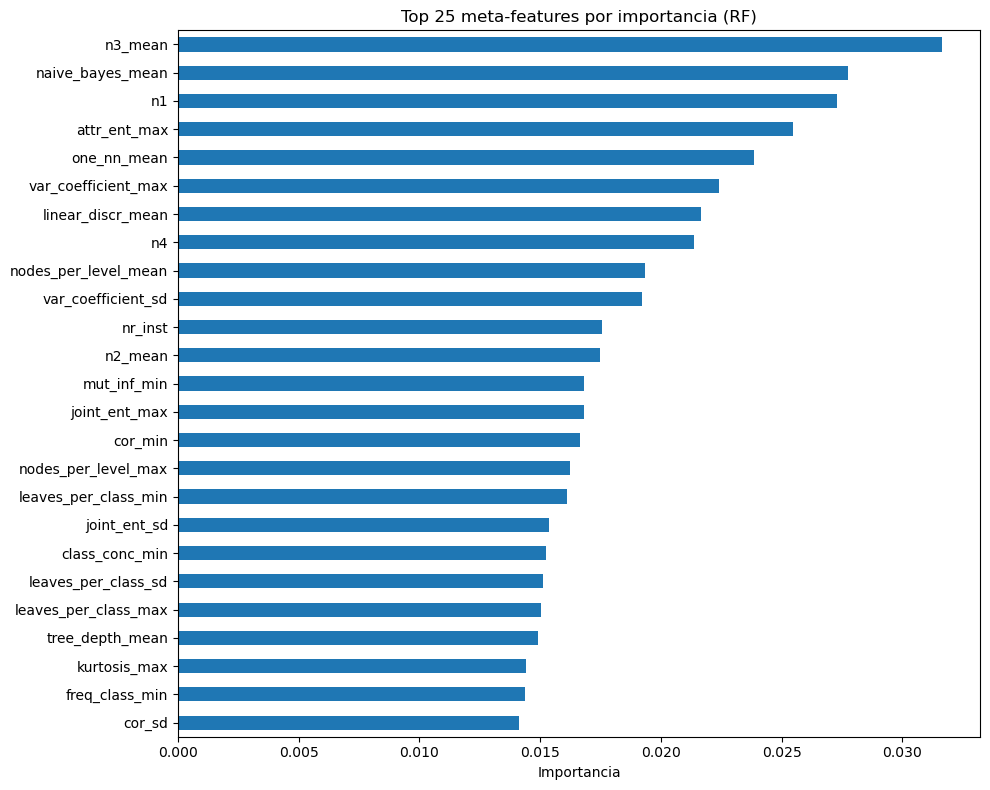

Features para 80% importancia: 54
Features para 90% importancia: 64
Features para 95% importancia: 70


In [4]:
# =============================================================================
# ANÁLISIS DE META-FEATURES 
# Orden: escalar → importancia RF 
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ─── Preparar X e y ──────────────────────────────────────────────────────────
score_cols   = [f"score_{sel}" for sel in ["chi2", "mutual_info", "f_classif"]]
cols_excluir = ["dataset_name", "best_selector"] + score_cols

X = meta_dataset_df.drop(columns=cols_excluir, errors='ignore')
X = X.dropna(axis=1, how="all")
X = X.loc[:, X.isnull().mean() < 0.50]
y = meta_dataset_df["best_selector"].values

print(f"Features iniciales: {X.shape[1]}")
print(f"Datasets: {X.shape[0]}\n")

# Imputar y escalar ANTES de cualquier análisis
imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()
X_imp   = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
X_sc    = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns)

# =============================================================================
# IMPORTANCIA SEGÚN RANDOMFOREST
# RF entrenado UNA VEZ sobre todos los datos → importancia global estable.
# No nos importa el accuracy, solo qué features usa para distinguir selectores.
# Usamos las 80 features completas — en análisis exploratorio más info es mejor.
# =============================================================================
rf_analisis = RandomForestClassifier(n_estimators=500, random_state=42) #aumento el número de árboles para calcular la importancia de forma más estable
rf_analisis.fit(X_sc.values, y)

importancias = pd.Series(
    rf_analisis.feature_importances_,
    index=X_sc.columns
).sort_values(ascending=False)

print(f"{'Feature':<30} {'Importancia':>12} {'Acumulada':>10}")
print("-" * 55)
acumulada = 0
for feat, imp in importancias.items():
    acumulada += imp
    print(f"{feat:<30} {imp:>12.4f} {acumulada:>9.1%}")

plt.figure(figsize=(10, 8))
importancias.head(25).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 25 meta-features por importancia (RF)")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

importancia_acumulada = importancias.cumsum()
for pct in [0.80, 0.90, 0.95]:
    n = (importancia_acumulada < pct).sum() + 1
    print(f"Features para {pct:.0%} importancia: {n}")

features_ordenadas = importancias.index.tolist()

In [5]:
# =============================================================================
# ABLACIÓN DE FEATURES — RF y GB con distintos cortes de features
# =============================================================================
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score

# features_ordenadas viene de la celda anterior (ranking sobre 80 features)
loo = LeaveOneOut()

print(f"{'Configuración':<20} {'RF':>8} {'GB':>8}")
print("-" * 38)

for n_features in [30, 40, 50, 60, 70, 80]:
    feats = features_ordenadas[:n_features] #seleccionamos el número de features deseado, por orden de importancia
    X_sel = X_sc[feats].values  # X_sc tiene las 80 features escaladas
    y_rf, y_gb = [], []

    for train_idx, test_idx in loo.split(X_sel):
        X_tr, X_te = X_sel[train_idx], X_sel[test_idx]
        y_tr = y[train_idx]

        rf = RandomForestClassifier(n_estimators=200, random_state=42)
        gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

        rf.fit(X_tr, y_tr)
        gb.fit(X_tr, y_tr)

        y_rf.append(rf.predict(X_te)[0])
        y_gb.append(gb.predict(X_te)[0])

    acc_rf = accuracy_score(y, y_rf)
    acc_gb = accuracy_score(y, y_gb)
    print(f"Top {n_features:<16} {acc_rf:>8.4f} {acc_gb:>8.4f}")

Configuración              RF       GB
--------------------------------------
Top 30                 0.5635   0.5873
Top 40                 0.5238   0.5397
Top 50                 0.5159   0.5317
Top 60                 0.5238   0.5000
Top 70                 0.5317   0.5397
Top 80                 0.4921   0.5317


Gráfica para comparar el rendimiento de los modelos GradientBoosting y RandomForest en función del número de meta-features utilizadas

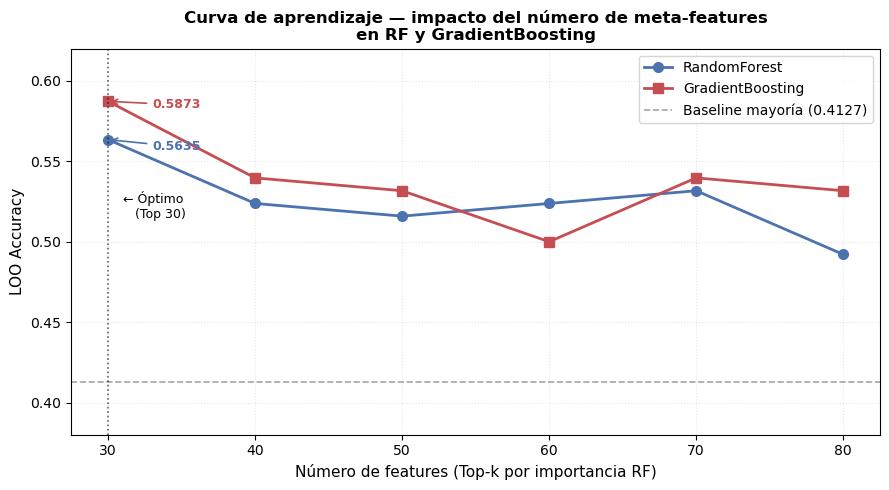

In [7]:
# =============================================================================
# GRÁFICA — Curva de apredndizaje de features
# =============================================================================
import matplotlib.pyplot as plt

n_features_list = [30, 40, 50, 60, 70, 80]
acc_rf = [0.5635, 0.5238, 0.5159, 0.5238, 0.5317, 0.4921]
acc_gb = [0.5873, 0.5397, 0.5317, 0.5000, 0.5397, 0.5317]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(n_features_list, acc_rf, "o-", color="#4C72B0",
        linewidth=2, markersize=7, label="RandomForest")
ax.plot(n_features_list, acc_gb, "s-", color="#C44E52",
        linewidth=2, markersize=7, label="GradientBoosting")

# Línea de referencia: baseline mayoría
ax.axhline(y=0.4127, color="gray", linestyle="--",
           linewidth=1.2, alpha=0.7, label="Baseline mayoría (0.4127)")

# Marcar el punto óptimo
ax.axvline(x=30, color="black", linestyle=":",
           linewidth=1.2, alpha=0.6)
ax.text(31, 0.515, "← Óptimo\n   (Top 30)",
        fontsize=9, color="black")

# Anotar los valores del Top 30
ax.annotate(f"0.5873", xy=(30, 0.5873), xytext=(33, 0.583),
            fontsize=9, color="#C44E52", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#C44E52", lw=1.2))
ax.annotate(f"0.5635", xy=(30, 0.5635), xytext=(33, 0.557),
            fontsize=9, color="#4C72B0", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#4C72B0", lw=1.2))

ax.set_xlabel("Número de features (Top-k por importancia RF)", fontsize=11)
ax.set_ylabel("LOO Accuracy", fontsize=11)
ax.set_title("Curva de aprendizaje — impacto del número de meta-features\n"
             "en RF y GradientBoosting", fontsize=12, fontweight="bold")
ax.set_xticks(n_features_list)
ax.set_ylim(0.38, 0.62)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, linestyle=":")

plt.tight_layout()
plt.savefig("ablacion_features.png", dpi=150, bbox_inches="tight")
plt.show()

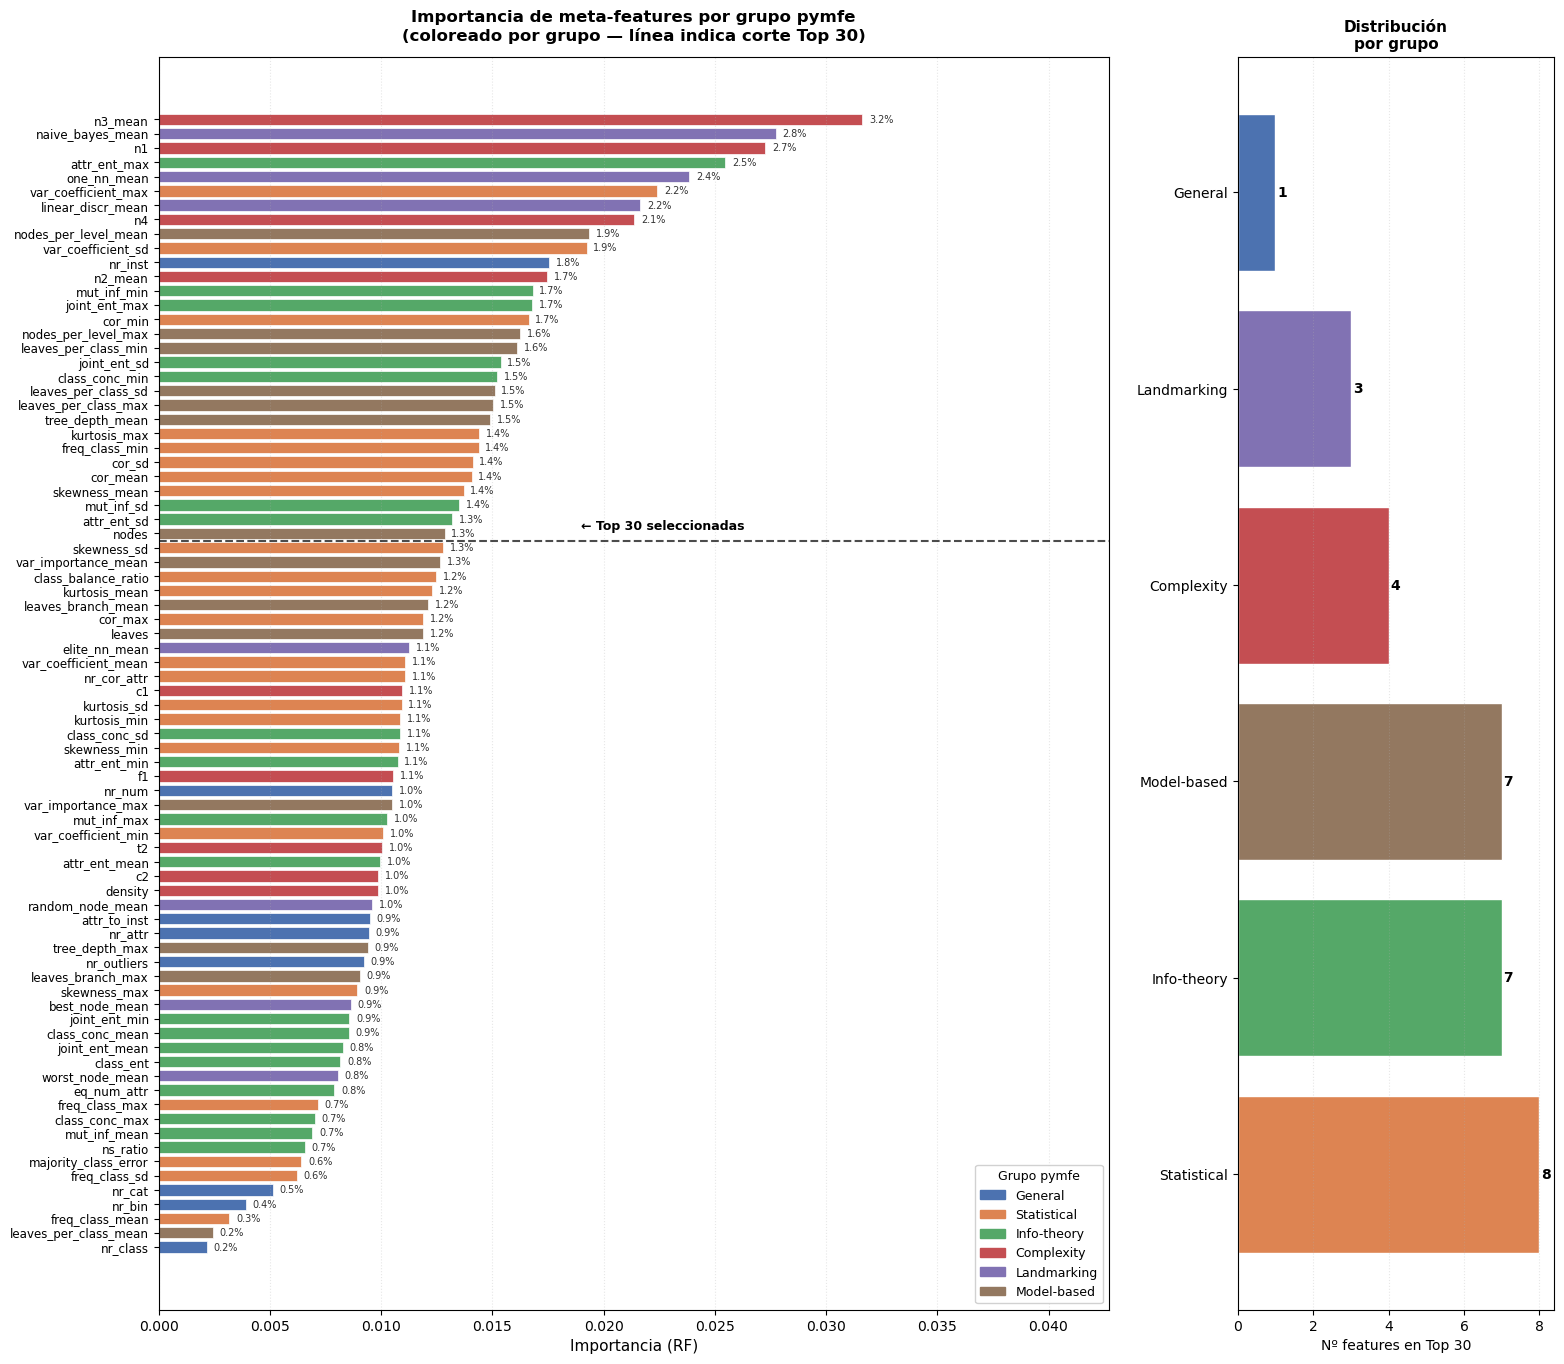

Gráfica guardada como 'importancia_meta_features.png'


In [18]:
# =============================================================================
# GRÁFICA — Importancia de meta-features coloreada por grupo pymfe
# =============================================================================

# ─── Asignar cada feature a su grupo pymfe ───────────────────────────────────
grupos = {
    # General
    "nr_inst":              "General",
    "nr_attr":              "General",
    "nr_class":             "General",
    "nr_num":               "General",
    "nr_cat":               "General",
    "nr_bin":               "General",
    "attr_to_inst":         "General",
    "nr_outliers":          "General",
    # Statistical
    "skewness_mean":        "Statistical",
    "skewness_sd":          "Statistical",
    "skewness_min":         "Statistical",
    "skewness_max":         "Statistical",
    "kurtosis_mean":        "Statistical",
    "kurtosis_sd":          "Statistical",
    "kurtosis_max":         "Statistical",
    "cor_mean":             "Statistical",
    "cor_sd":               "Statistical",
    "cor_min":              "Statistical",
    "cor_max":              "Statistical",
    "var_coefficient_mean": "Statistical",
    "class_balance_ratio":  "Statistical",
    "freq_class_max":       "Statistical",
    "kurtosis_min":         "Statistical",
    "var_coefficient_sd":   "Statistical",
    "var_coefficient_min":  "Statistical",
    "var_coefficient_max":  "Statistical",
    "nr_cor_attr":          "Statistical",
    "majority_class_error": "Statistical",
    "freq_class_mean":      "Statistical",
    "freq_class_sd":        "Statistical",
    "freq_class_min":       "Statistical",
    "freq_class_max":       "Statistical",
    # Info-theory
    "class_ent":            "Info-theory",
    "attr_ent_mean":        "Info-theory",
    "attr_ent_sd":          "Info-theory",
    "attr_ent_min":         "Info-theory",
    "attr_ent_max":         "Info-theory",
    "mut_inf_mean":         "Info-theory",
    "mut_inf_sd":           "Info-theory",
    "mut_inf_min":          "Info-theory",
    "mut_inf_max":          "Info-theory",
    "joint_ent_mean":       "Info-theory",
    "joint_ent_min":        "Info-theory",
    "joint_ent_max":        "Info-theory",
    "class_conc_mean":      "Info-theory",
    "class_conc_sd":        "Info-theory",
    "class_conc_min":       "Info-theory",
    "class_conc_max":       "Info-theory",
    "eq_num_attr":          "Info-theory",
    "ns_ratio":             "Info-theory",
    "joint_ent_sd":         "Info-theory",
    "c2":                   "Complexity",
    # Complexity
    "density":              "Complexity",
    "c1":                   "Complexity",
    "n1":                   "Complexity",
    "t2":                   "Complexity",
    "f1":                   "Complexity",
    "n2_mean":              "Complexity",
    "n3_mean":              "Complexity",
    "n4":                   "Complexity",
    # Landmarking
    "best_node_mean":       "Landmarking",
    "random_node_mean":     "Landmarking",
    "linear_discr_mean":    "Landmarking",
    "elite_nn_mean":        "Landmarking",
    "naive_bayes_mean":     "Landmarking",
    "one_nn_mean":          "Landmarking",
    "worst_node_mean":      "Landmarking",
    # Model-based
    "nodes":                "Model-based",
    "tree_depth_mean":      "Model-based",
    "var_importance_mean":  "Model-based",
    "var_importance_max":   "Model-based",
    "leaves_per_class_sd":  "Model-based",
    "leaves_per_class_max": "Model-based",
    "leaves":               "Model-based",
    "tree_depth_max":       "Model-based",
    "leaves_branch_mean":   "Model-based",
    "leaves_branch_max":    "Model-based",
    "nodes_per_level_mean": "Model-based",
    "nodes_per_level_max":  "Model-based",
    "leaves_per_class_mean":"Model-based",
    "leaves_per_class_min": "Model-based",
    
}

# Colores por grupo
colores_grupo = {
    "General":     "#4C72B0",
    "Statistical":  "#DD8452",
    "Info-theory":  "#55A868",
    "Complexity":   "#C44E52",
    "Landmarking":  "#8172B3",
    "Model-based":  "#937860",
}

# Preparar datos del ranking (top 61 features)
n_mostrar = 80
feats_plot   = importancias.index[:n_mostrar].tolist()
vals_plot    = importancias.values[:n_mostrar]
colores_plot = [colores_grupo.get(grupos.get(f, "General"), "#999999")
                for f in feats_plot]

# ─── Figura principal ────────────────────────────────────────────────────────
fig, (ax_main, ax_pie) = plt.subplots(
    1, 2,
    figsize=(16, 14),
    gridspec_kw={"width_ratios": [3, 1]}
)

# ── Gráfica principal: barras horizontales ────────────────────────────────────
bars = ax_main.barh(
    range(n_mostrar), vals_plot,
    color=colores_plot, edgecolor="white", linewidth=0.5
)
ax_main.invert_yaxis()
ax_main.set_yticks(range(n_mostrar))
ax_main.set_yticklabels(feats_plot, fontsize=8.5)

# Línea de corte en top 30
ax_main.axhline(y=29.5, color="black", linestyle="--", linewidth=1.5, alpha=0.7)
ax_main.text(
    vals_plot[0] * 0.6, 29.5 - 0.8,
    "← Top 30 seleccionadas",
    fontsize=9, color="black", fontweight="bold"
)

# Porcentaje individual de cada feature sobre el total
for i, (feat, val) in enumerate(zip(feats_plot, vals_plot)):
    ax_main.text(
        val + 0.0003, i,
        f"{val:.1%}",
        va="center", fontsize=7, color="#333333"
    )

ax_main.set_xlabel("Importancia (RF)", fontsize=11)
ax_main.set_title(
    "Importancia de meta-features por grupo pymfe\n"
    "(coloreado por grupo — línea indica corte Top 30)",
    fontsize=12, fontweight="bold", pad=12
)
ax_main.set_xlim(0, vals_plot[0] * 1.35)
ax_main.grid(axis="x", alpha=0.3, linestyle=":")

# Leyenda
patches = [
    mpatches.Patch(color=c, label=g)
    for g, c in colores_grupo.items()
]
ax_main.legend(
    handles=patches, loc="lower right",
    fontsize=9, title="Grupo pymfe", title_fontsize=9,
    framealpha=0.9
)

# ── Gráfico secundario: distribución por grupo en Top 30 ─────────────────────
top30_feats  = importancias.index[:30].tolist()
top30_grupos = [grupos.get(f, "General") for f in top30_feats]

conteo = {}
for g in top30_grupos:
    conteo[g] = conteo.get(g, 0) + 1

# Ordenar por conteo
conteo_sorted = dict(sorted(conteo.items(), key=lambda x: x[1], reverse=True))

ax_pie.barh(
    list(conteo_sorted.keys()),
    list(conteo_sorted.values()),
    color=[colores_grupo[g] for g in conteo_sorted.keys()],
    edgecolor="white"
)
ax_pie.set_xlabel("Nº features en Top 30", fontsize=10)
ax_pie.set_title("Distribución\npor grupo", fontsize=11, fontweight="bold")
ax_pie.grid(axis="x", alpha=0.3, linestyle=":")

for i, (g, n) in enumerate(conteo_sorted.items()):
    ax_pie.text(n + 0.05, i, str(n), va="center", fontsize=10, fontweight="bold")

plt.tight_layout(pad=2.0)
plt.savefig("importancia_meta_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada como 'importancia_meta_features.png'")

C:\Users\pablo\anaconda3\envs\entornoIA2425\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


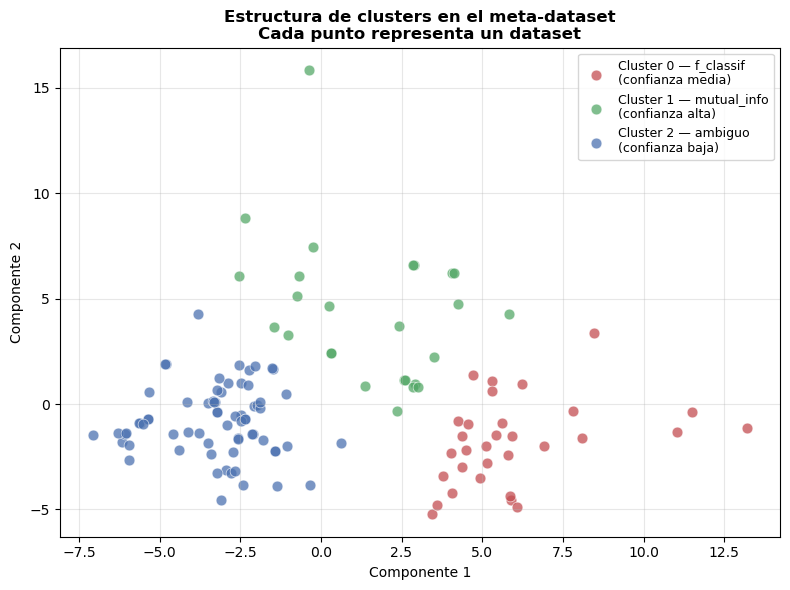

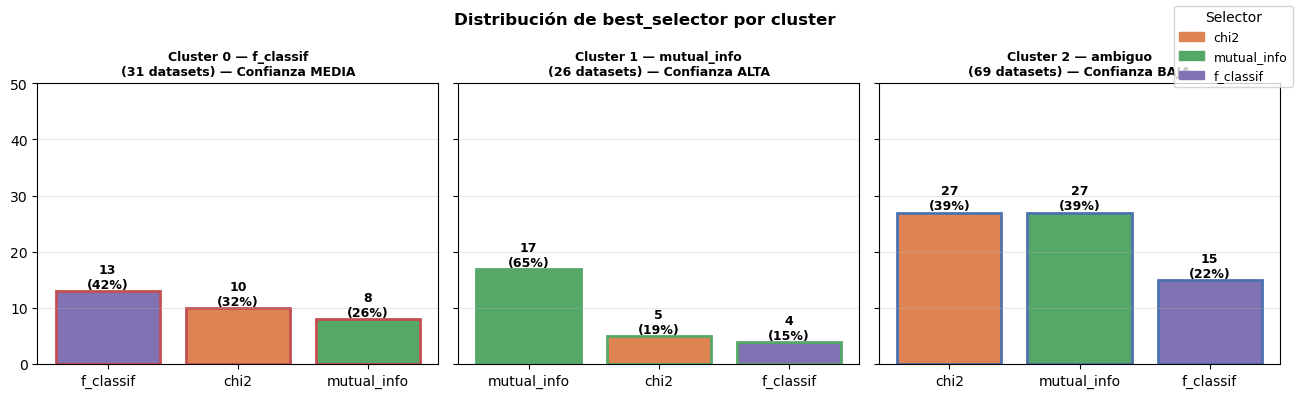

Gráficas guardadas:
  clustering_estructura.png
  clustering_selectores.png


In [30]:
# =============================================================================
# EXPERIMENTO 2 — CELDA 3: Visualizaciones del clustering k=3
# =============================================================================
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ─── Reproducir datos ────────────────────────────────────────────────────────
score_cols   = [f"score_{s}" for s in ["chi2", "mutual_info", "f_classif"]]
cols_excluir = ["dataset_name", "best_selector"] + score_cols

X_raw = meta_dataset_df.drop(columns=cols_excluir, errors='ignore')
X_raw = X_raw.dropna(axis=1, how="all")
X_raw = X_raw.loc[:, X_raw.isnull().mean() < 0.50]

imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()
X_imp   = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)
X_sc    = pd.DataFrame(scaler.fit_transform(X_imp),  columns=X_raw.columns)

y_label = meta_dataset_df["best_selector"].values

# ─── Clustering k=3 ──────────────────────────────────────────────────────────
km     = KMeans(n_clusters=3, random_state=42, n_init=20)
labels = km.fit_predict(X_sc.values)

# ─── Proyección 2D para visualización ────────────────────────────────────────
pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_sc.values)

# ─── Colores ─────────────────────────────────────────────────────────────────
colores_cluster = {0: "#C44E52", 1: "#55A868", 2: "#4C72B0"}
nombres_cluster = {
    0: "Cluster 0 — f_classif\n(confianza media)",
    1: "Cluster 1 — mutual_info\n(confianza alta)",
    2: "Cluster 2 — ambiguo\n(confianza baja)",
}
colores_selector = {
    "chi2":        "#DD8452",
    "mutual_info": "#55A868",
    "f_classif":   "#8172B3",
}

# =============================================================================
# GRÁFICA 1 — Estructura de clusters en el meta-dataset
# Cada punto es un dataset. Los colores muestran los 3 grupos encontrados.
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 6))

for c, color in colores_cluster.items():
    mask = labels == c
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=color, label=nombres_cluster[c],
        alpha=0.75, s=60, edgecolors="white", linewidth=0.5
    )

ax.set_title(
    "Estructura de clusters en el meta-dataset\n"
    "Cada punto representa un dataset",
    fontweight="bold", fontsize=12
)
ax.set_xlabel("Componente 1")
ax.set_ylabel("Componente 2")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("clustering_estructura.png", dpi=150, bbox_inches="tight")
plt.show()

# =============================================================================
# GRÁFICA 2 — Distribución de best_selector por cluster
# Muestra qué selector domina en cada grupo y con qué confianza
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

info_clusters = {
    0: ("Cluster 0 — f_classif", "Confianza MEDIA", "#C44E52"),
    1: ("Cluster 1 — mutual_info", "Confianza ALTA",  "#55A868"),
    2: ("Cluster 2 — ambiguo",     "Confianza BAJA",  "#4C72B0"),
}

df_an = meta_dataset_df.copy()
df_an["cluster"] = labels

for i, c in enumerate([0, 1, 2]):
    sub    = df_an[df_an["cluster"] == c]
    vc     = sub["best_selector"].value_counts()
    titulo, confianza, color_borde = info_clusters[c]

    bars = axes[i].bar(
        vc.index, vc.values,
        color=[colores_selector[s] for s in vc.index],
        edgecolor=color_borde, linewidth=2
    )
    axes[i].set_title(
        f"{titulo}\n({len(sub)} datasets) — {confianza}",
        fontweight="bold", fontsize=9
    )
    axes[i].set_ylim(0, 50)
    axes[i].grid(axis="y", alpha=0.3)

    # Número y porcentaje encima de cada barra
    for bar, (sel, cnt) in zip(bars, vc.items()):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            cnt + 0.5, f"{cnt}\n({cnt/len(sub):.0%})",
            ha="center", fontsize=9, fontweight="bold"
        )

# Leyenda común
patches = [mpatches.Patch(color=c, label=s)
           for s, c in colores_selector.items()]
fig.legend(handles=patches, loc="upper right",
           fontsize=9, title="Selector")

plt.suptitle("Distribución de best_selector por cluster",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("clustering_selectores.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gráficas guardadas:")
print("  clustering_estructura.png")
print("  clustering_selectores.png")

In [32]:
# =============================================================================
# EXPERIMENTO 2 — CELDA 4: Conexión clustering con modelo supervisado (GB)
# Pregunta: ¿acierta GB más en clusters con selector dominante claro?
# =============================================================================
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score

# ─── Generar predicciones GB Top 30 ──────────────────────────────────────────
# Se genera aquí directamente para no depender de variables de celdas anteriores
feats  = features_ordenadas[:30]
X_sel  = X_sc[feats].values

loo    = LeaveOneOut()
y_pred_gb_top30 = []

for train_idx, test_idx in loo.split(X_sel):
    X_tr, X_te = X_sel[train_idx], X_sel[test_idx]
    y_tr       = y[train_idx]
    gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
    gb.fit(X_tr, y_tr)
    y_pred_gb_top30.append(gb.predict(X_te)[0])

print(f"GB Top 30 — LOO Accuracy: {accuracy_score(y, y_pred_gb_top30):.4f}\n")

# ─── Análisis por cluster ─────────────────────────────────────────────────────
df_an = meta_dataset_df.copy()
df_an["cluster"]     = labels
df_an["pred_gb"]     = y_pred_gb_top30
df_an["correcto_gb"] = [r == p for r, p in
                        zip(df_an["best_selector"], df_an["pred_gb"])]

info_clusters = {
    0: ("Cluster 0 — f_classif",   "MEDIA"),
    1: ("Cluster 1 — mutual_info", "ALTA"),
    2: ("Cluster 2 — ambiguo",     "BAJA"),
}

print("=" * 55)
print("ACCURACY DE GB POR CLUSTER")
print("=" * 55)

for c in [0, 1, 2]:
    sub             = df_an[df_an["cluster"] == c]
    nombre, confianza = info_clusters[c]
    acc             = sub["correcto_gb"].mean()
    n               = len(sub)
    n_ok            = sub["correcto_gb"].sum()
    print(f"\n{nombre} (confianza {confianza}, {n} datasets)")
    print(f"  Aciertos: {n_ok}/{n} → accuracy = {acc:.4f}")



GB Top 30 — LOO Accuracy: 0.5873

ACCURACY DE GB POR CLUSTER

Cluster 0 — f_classif (confianza MEDIA, 31 datasets)
  Aciertos: 13/31 → accuracy = 0.4194

Cluster 1 — mutual_info (confianza ALTA, 26 datasets)
  Aciertos: 20/26 → accuracy = 0.7692

Cluster 2 — ambiguo (confianza BAJA, 69 datasets)
  Aciertos: 41/69 → accuracy = 0.5942


CARACTERIZACIÓN DE DATASETS POR CLUSTER
                              C0 — f_classif   C1 — mutual_info       C2 — ambiguo
Estadística                                                                       
Nº instancias              3646.65 ± 4261.76  6608.04 ± 5557.80  2927.16 ± 3344.87
Nº features                  127.00 ± 200.63      39.15 ± 61.74     75.72 ± 175.37
Nº clases                      19.35 ± 27.26        4.46 ± 2.47        2.20 ± 0.56
Entropía de clases (bits)        3.59 ± 1.13        1.78 ± 0.71        0.87 ± 0.33
Error clase mayoritaria          0.88 ± 0.06        0.59 ± 0.16        0.32 ± 0.16
Ratio de balance                 0.81 ± 0.30        0.54 ± 0.34        0.45 ± 0.32
Nº features numéricas        117.84 ± 201.46      37.62 ± 62.48     61.58 ± 176.25
Nº features categóricas         9.16 ± 43.30        1.54 ± 2.66      14.14 ± 35.14


C:\Users\pablo\AppData\Local\Temp\ipykernel_17784\3304915557.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\pablo\AppData\Local\Temp\ipykernel_17784\3304915557.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden, rotation=12, fontsize=9)
C:\Users\pablo\AppData\Local\Temp\ipykernel_17784\3304915557.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\pablo\AppData\Local\Temp\ipykernel_17784\3304915557.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(or

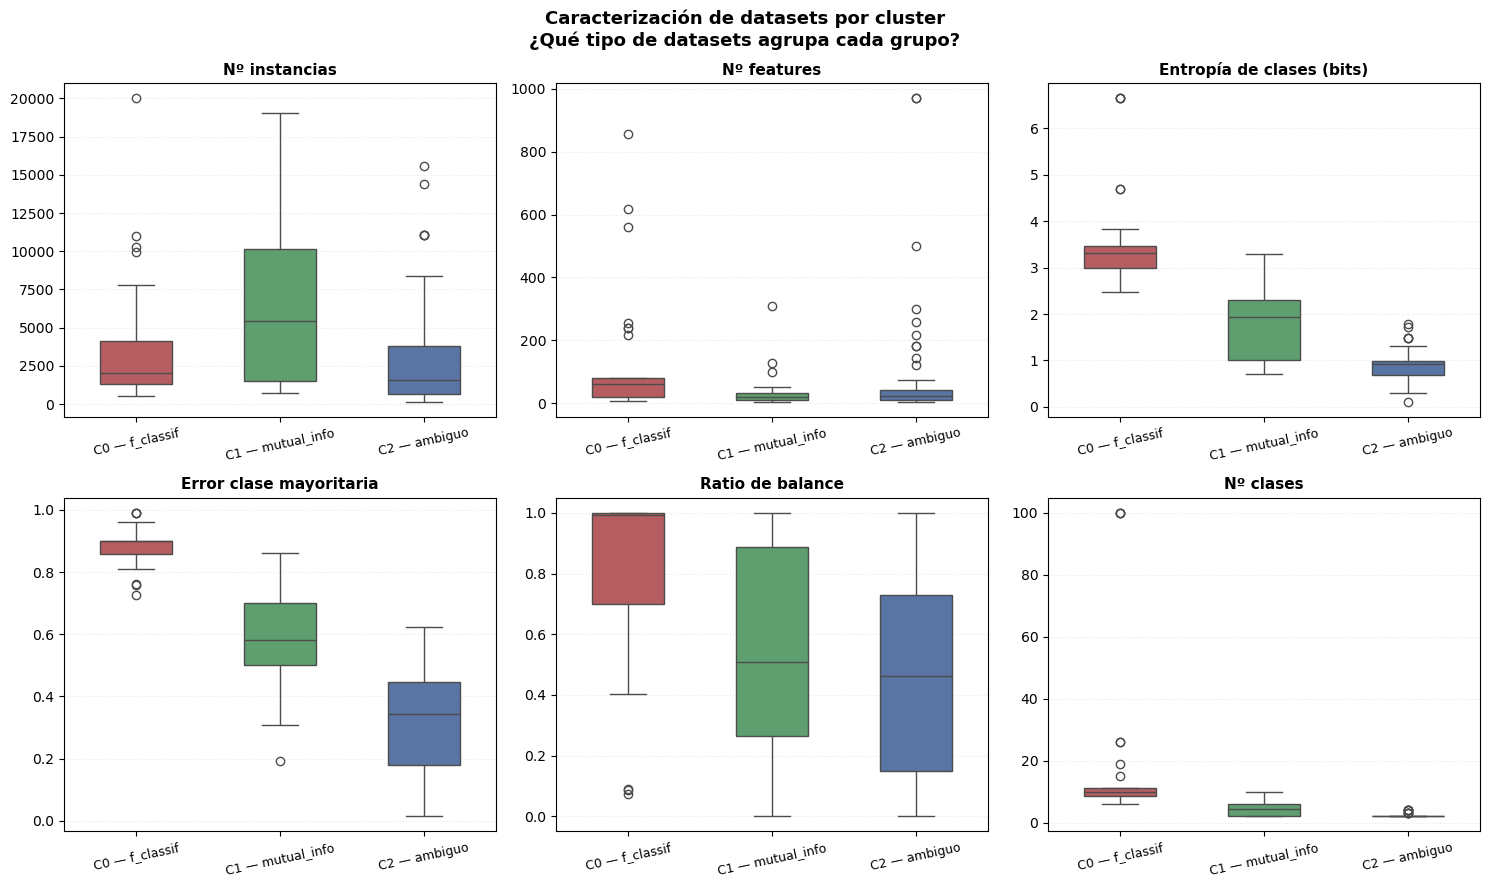


Gráfica guardada como 'clustering_caracterizacion.png'


In [29]:
# =============================================================================
# EXPERIMENTO 2 — Caracterización de datasets por cluster
# ¿Qué tipo de datasets agrupa cada cluster?
# =============================================================================


# ─── Preparar dataframe ───────────────────────────────────────────────────────
# Usamos meta_dataset_df SIN escalar para que los valores sean interpretables
# (nr_inst en número real de instancias, class_ent en bits reales, etc.)
df_clusters = meta_dataset_df.copy()
df_clusters["cluster"] = labels

nombres_cluster = {
    0: "C0 — f_classif",
    1: "C1 — mutual_info",
    2: "C2 — ambiguo",
}
df_clusters["cluster_nombre"] = df_clusters["cluster"].map(nombres_cluster)

# ─── Estadísticas a analizar ─────────────────────────────────────────────────
estadisticas = {
    "nr_inst":             "Nº instancias",
    "nr_attr":             "Nº features",
    "nr_class":            "Nº clases",
    "class_ent":           "Entropía de clases (bits)",
    "majority_class_error":"Error clase mayoritaria",
    "class_balance_ratio": "Ratio de balance",
    "nr_num":              "Nº features numéricas",
    "nr_cat":              "Nº features categóricas",
}

# =============================================================================
# TABLA — Media y desviación de cada estadística por cluster
# =============================================================================
print("=" * 70)
print("CARACTERIZACIÓN DE DATASETS POR CLUSTER")
print("=" * 70)

filas = []
for feat, nombre in estadisticas.items():
    if feat not in df_clusters.columns:
        continue
    fila = {"Estadística": nombre}
    for c in [0, 1, 2]:
        sub = df_clusters[df_clusters["cluster"] == c][feat].dropna()
        # Formato: media ± std
        fila[nombres_cluster[c]] = f"{sub.mean():.2f} ± {sub.std():.2f}"
    filas.append(fila)

tabla = pd.DataFrame(filas).set_index("Estadística")
print(tabla.to_string())

# =============================================================================
# GRÁFICA — Boxplots: distribución de cada estadística por cluster
# Boxplot es mejor que barras porque muestra la dispersión real,
# no solo la media — importante con pocos datasets por cluster
# =============================================================================
features_plot = [
    ("nr_inst",              "Nº instancias"),
    ("nr_attr",              "Nº features"),
    ("class_ent",            "Entropía de clases (bits)"),
    ("majority_class_error", "Error clase mayoritaria"),
    ("class_balance_ratio",  "Ratio de balance"),
    ("nr_class",             "Nº clases"),
]
features_plot = [(f, n) for f, n in features_plot if f in df_clusters.columns]

colores = {
    "C0 — f_classif":  "#C44E52",
    "C1 — mutual_info":"#55A868",
    "C2 — ambiguo":    "#4C72B0",
}
orden = ["C0 — f_classif", "C1 — mutual_info", "C2 — ambiguo"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for i, (feat, nombre) in enumerate(features_plot):
    ax = axes[i]
    sns.boxplot(
        data=df_clusters,
        x="cluster_nombre",
        y=feat,
        palette=colores,
        order=orden,
        width=0.5,
        ax=ax,
    )
    ax.set_title(nombre, fontweight="bold", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(orden, rotation=12, fontsize=9)
    ax.grid(axis="y", alpha=0.3, linestyle=":")

plt.suptitle(
    "Caracterización de datasets por cluster\n"
    "¿Qué tipo de datasets agrupa cada grupo?",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("clustering_caracterizacion.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nGráfica guardada como 'clustering_caracterizacion.png'")